In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, applications
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# CNN 

In [2]:
def create_model(input_shape=(224, 224, 3), num_classes=None):
    """
    Create a CNN model for point machine classification
    
    Args:
        input_shape: Input image dimensions (height, width, channels)
        num_classes: Number of classes to predict
    
    Returns:
        Compiled Keras model
    """
    # Use a pre-trained model as the base
    base_model = applications.ResNet50V2(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    
    # Freeze the base model layers
    base_model.trainable = False
    
    # Create the model
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    # Compile the model
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model


## Train the model 

In [3]:
def train_model(dataset_dir, model_save_path='model', batch_size=32, epochs=50):
    """
    Train the model on the dataset
    
    Args:
        dataset_dir: Directory containing train/val/test splits
        model_save_path: Directory to save the trained model
        batch_size: Batch size for training
        epochs: Number of epochs to train
        
    Returns:
        Training history and the trained model
    """
    # Create directory for saving model if it doesn't exist
    if not os.path.exists(model_save_path):
        os.makedirs(model_save_path)
    
    # Data paths
    train_dir = os.path.join(dataset_dir, 'train')
    val_dir = os.path.join(dataset_dir, 'val')
    
    # Get class names and number of classes
    class_names = sorted(os.listdir(train_dir))
    num_classes = len(class_names)
    
    print(f"Found {num_classes} classes: {class_names}")
    
    # Create data generators with augmentation for training
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )
    
    # Only rescale for validation
    val_datagen = ImageDataGenerator(rescale=1./255)
    
    # Create generators
    train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=(224, 224),
        batch_size=batch_size,
        class_mode='categorical'
    )
    
    val_generator = val_datagen.flow_from_directory(
        val_dir,
        target_size=(224, 224),
        batch_size=batch_size,
        class_mode='categorical'
    )
    
    # Create and compile the model
    model = create_model(num_classes=num_classes)
    model.summary()
    
    # Callbacks for training
    checkpoint = ModelCheckpoint(
        os.path.join(model_save_path, 'best_model.h5'),
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
    
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    )
    
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
    
    # Train the model
    history = model.fit(
        train_generator,
        steps_per_epoch=train_generator.samples // batch_size,
        epochs=epochs,
        validation_data=val_generator,
        validation_steps=val_generator.samples // batch_size,
        callbacks=[checkpoint, early_stopping, reduce_lr]
    )
    
    # Save the final model
    model.save(os.path.join(model_save_path, 'final_model.h5'))
    
    # Save class names for inference
    with open(os.path.join(model_save_path, 'class_names.txt'), 'w') as f:
        for class_name in class_names:
            f.write(f"{class_name}\n")
    
    return history, model

## model evaluation 

In [4]:
def evaluate_model(model, dataset_dir, batch_size=32):
    """
    Evaluate the model on the test set
    
    Args:
        model: Trained Keras model
        dataset_dir: Directory containing the dataset splits
        batch_size: Batch size for evaluation
    """
    test_dir = os.path.join(dataset_dir, 'test')
    
    # Create data generator for test set
    test_datagen = ImageDataGenerator(rescale=1./255)
    
    test_generator = test_datagen.flow_from_directory(
        test_dir,
        target_size=(224, 224),
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=False
    )
    
    # Evaluate the model
    print("Evaluating model on test set...")
    test_loss, test_accuracy = model.evaluate(test_generator)
    print(f"Test accuracy: {test_accuracy:.4f}")
    print(f"Test loss: {test_loss:.4f}")
    
    # Get class predictions
    test_steps = np.ceil(test_generator.samples / batch_size)
    predictions = model.predict(test_generator, steps=test_steps)
    predicted_classes = np.argmax(predictions, axis=1)
    
    # Get true labels
    true_classes = test_generator.classes[:len(predicted_classes)]
    class_names = list(test_generator.class_indices.keys())
    
    # Generate classification report
    print("\nClassification Report:")
    report = classification_report(true_classes, predicted_classes, target_names=class_names)
    print(report)
    
    # Generate confusion matrix
    cm = confusion_matrix(true_classes, predicted_classes)
    
    # Plot confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.savefig('confusion_matrix.png')
    plt.show()
    
    # Save classification report to file
    with open('classification_report.txt', 'w') as f:
        f.write(report)
    
    return test_accuracy, predictions, true_classes

In [5]:
def plot_training_history(history):
    """
    Plot training and validation accuracy/loss
    
    Args:
        history: Training history from model.fit()
    """
    # Plot training & validation accuracy
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    
    # Plot training & validation loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    
    plt.tight_layout()
    plt.savefig('training_history.png')
    plt.show()

In [6]:
def fine_tune_model(base_model, dataset_dir, model_save_path='fine_tuned_model', 
                   batch_size=32, epochs=20, learning_rate=1e-5):
    """
    Fine-tune the pre-trained model by unfreezing some layers
    
    Args:
        base_model: Trained model to fine-tune
        dataset_dir: Directory containing train/val/test splits
        model_save_path: Directory to save the fine-tuned model
        batch_size: Batch size for training
        epochs: Number of epochs for fine-tuning
        learning_rate: Learning rate for fine-tuning (should be small)
    
    Returns:
        Fine-tuning history and the fine-tuned model
    """
    # Create directory for saving model if it doesn't exist
    if not os.path.exists(model_save_path):
        os.makedirs(model_save_path)
    
    # Data paths
    train_dir = os.path.join(dataset_dir, 'train')
    val_dir = os.path.join(dataset_dir, 'val')
    
    # Create data generators with augmentation for training
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )
    
    # Only rescale for validation
    val_datagen = ImageDataGenerator(rescale=1./255)
    
    # Create generators
    train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=(224, 224),
        batch_size=batch_size,
        class_mode='categorical'
    )
    
    val_generator = val_datagen.flow_from_directory(
        val_dir,
        target_size=(224, 224),
        batch_size=batch_size,
        class_mode='categorical'
    )
    
    # Unfreeze some layers for fine-tuning
    # First, find the ResNet50V2 base model
    for layer in base_model.layers:
        if isinstance(layer, tf.keras.models.Model):  # This is the base_model
            # Unfreeze the last 30 layers of the base model
            for i, layer in enumerate(layer.layers):
                if i >= len(layer.layers) - 30:  # Only unfreeze the last 30 layers
                    layer.trainable = True
                else:
                    layer.trainable = False
            break
    
    # Recompile the model with a lower learning rate
    base_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # Callbacks for training
    checkpoint = ModelCheckpoint(
        os.path.join(model_save_path, 'best_model.h5'),
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
    
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True,
        verbose=1
    )
    
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
    
    # Fine-tune the model
    print("Fine-tuning the model...")
    fine_tune_history = base_model.fit(
        train_generator,
        steps_per_epoch=train_generator.samples // batch_size,
        epochs=epochs,
        validation_data=val_generator,
        validation_steps=val_generator.samples // batch_size,
        callbacks=[checkpoint, early_stopping, reduce_lr]
    )
    
    # Save the final fine-tuned model
    base_model.save(os.path.join(model_save_path, 'fine_tuned_model.h5'))
    
    return fine_tune_history, base_model


## main function 

Training the initial model...
Found 16 classes: ['129_130', '159_160', 'PT101_102', 'PT119_120', 'PT_101_102', 'PT_101___102', 'PT_103_104', 'PT_109_110', 'PT_111___112', 'PT_119_120', 'PT_119___120', 'PT_121_122', 'PT_129_130', 'PT_135___136', 'PT_157___158', 'PT_189___190']
Found 1120 images belonging to 16 classes.
Found 240 images belonging to 16 classes.
94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 81s 1us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │         4,112 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,752,400 (94.42 MB)

 Trainable params: 1,186,064 (4.52 MB)

...

35/35 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.3260 - loss: 2.1254 - val_accuracy: 0.4241 - val_loss: 1.7096 - learning_rate: 0.0010
Epoch 19/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3262 - loss: 2.0328
Epoch 19: val_accuracy improved from 0.42411 to 0.42857, saving model to model/best_model.h5


35/35 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.3266 - loss: 2.0330 - val_accuracy: 0.4286 - val_loss: 1.6757 - learning_rate: 0.0010
Epoch 20/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3280 - loss: 2.0875
Epoch 20: val_accuracy did not improve from 0.42857
35/35 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.3283 - loss: 2.0862 - val_accuracy: 0.4152 - val_loss: 1.8294 - learning_rate: 0.0010
Epoch 21/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3550 - loss: 2.0022
Epoch 21: val_accuracy improved from 0.42857 to 0.46875, saving model to model/best_model.h5


35/35 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.3549 - loss: 2.0026 - val_accuracy: 0.4688 - val_loss: 1.6364 - learning_rate: 0.0010
Epoch 22/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3701 - loss: 1.9688
Epoch 22: val_accuracy did not improve from 0.46875
35/35 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.3696 - loss: 1.9695 - val_accuracy: 0.4420 - val_loss: 1.8170 - learning_rate: 0.0010
Epoch 23/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3627 - loss: 1.8953
Epoch 23: val_accuracy did not improve from 0.46875
35/35 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.3621 - loss: 1.8967 - val_accuracy: 0.4598 - val_loss: 1.5992 - learning_rate: 0.0010
Epoch 24/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3798 - loss: 1.8954
Epoch 24: val_accuracy did not improve from 0.46875
35/35 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.3795 - loss: 1.8967 - val_accuracy: 0.4330 - val_loss: 1.7511 - learning_rate: 0.0010
Epoch 25/30
35/35 ━━━━━━━━━━━━━━━━━━

35/35 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.3715 - loss: 1.8778 - val_accuracy: 0.4955 - val_loss: 1.5892 - learning_rate: 0.0010
Epoch 26/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3518 - loss: 1.9807
Epoch 26: val_accuracy did not improve from 0.49554
35/35 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.3516 - loss: 1.9808 - val_accuracy: 0.4732 - val_loss: 1.6583 - learning_rate: 0.0010
Epoch 27/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3648 - loss: 1.8467
Epoch 27: val_accuracy did not improve from 0.49554
35/35 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.3645 - loss: 1.8488 - val_accuracy: 0.4420 - val_loss: 1.7124 - learning_rate: 0.0010
Epoch 28/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3834 - loss: 1.9363
Epoch 28: val_accuracy improved from 0.49554 to 0.51786, saving model to model/best_model.h5


35/35 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.3830 - loss: 1.9364 - val_accuracy: 0.5179 - val_loss: 1.5488 - learning_rate: 0.0010
Epoch 29/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3785 - loss: 1.8847
Epoch 29: val_accuracy did not improve from 0.51786
35/35 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.3789 - loss: 1.8844 - val_accuracy: 0.5045 - val_loss: 1.5221 - learning_rate: 0.0010
Epoch 30/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4050 - loss: 1.7824
Epoch 30: val_accuracy did not improve from 0.51786
35/35 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.4045 - loss: 1.7835 - val_accuracy: 0.5089 - val_loss: 1.5360 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 29.


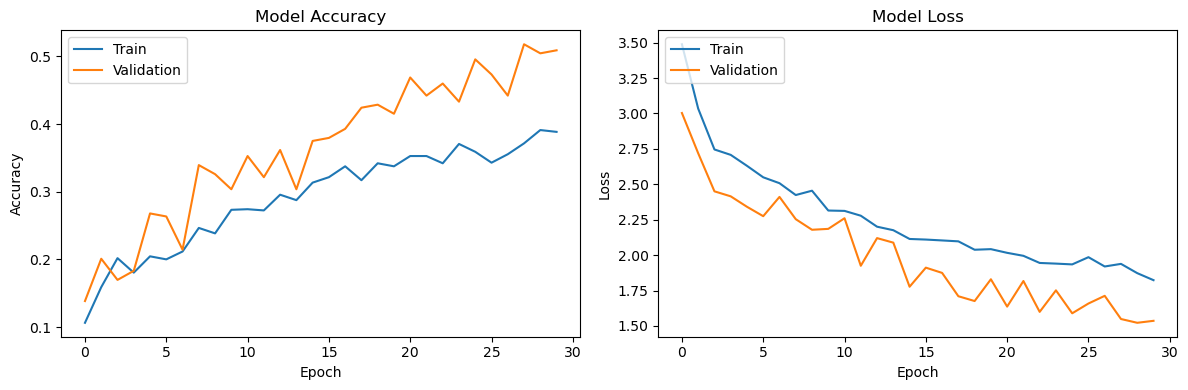

Found 240 images belonging to 16 classes.
Evaluating model on test set...
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.5381 - loss: 1.4533
Test accuracy: 0.5125
Test loss: 1.5358


TypeError: 'numpy.float64' object cannot be interpreted as an integer

In [7]:
def main():
    DATASET_DIR = "dataset_split"
    
    # Train the model
    print("Training the initial model...")
    history, model = train_model(DATASET_DIR, epochs=30)
    
    # Plot training history
    plot_training_history(history)
    
    # Evaluate the model
    evaluate_model(model, DATASET_DIR)
    
    # Fine-tune the model
    print("\nFine-tuning the model...")
    ft_history, ft_model = fine_tune_model(model, DATASET_DIR, epochs=15)
    
    # Plot fine-tuning history
    plot_training_history(ft_history)
    
    # Evaluate the fine-tuned model
    print("\nEvaluating the fine-tuned model:")
    evaluate_model(ft_model, DATASET_DIR)
    
    print("\nModel training and evaluation complete!")

if __name__ == "__main__":
    main()